Processing frame 1265/1269
LK time: 0.00415 sec
Farneback time: 0.24620 sec

1. Lucas-Kanade Optical Flow


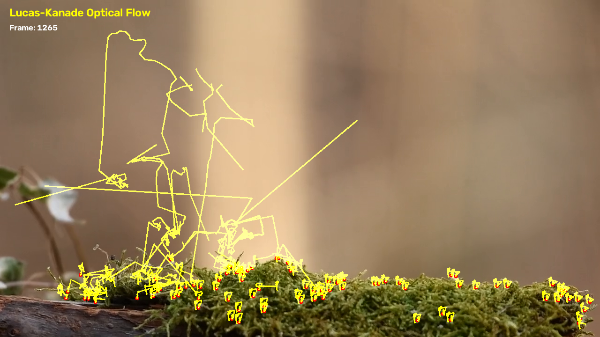


2. Farneback Dense Optical Flow


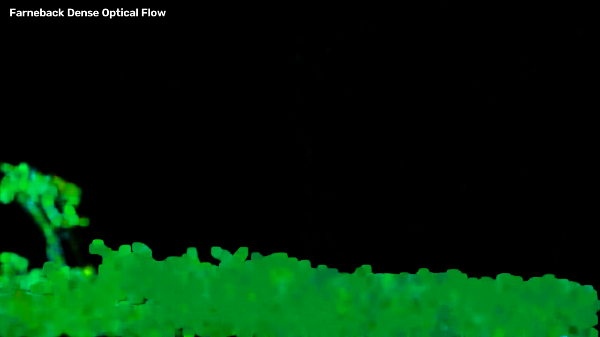


3. Farneback Motion Vectors


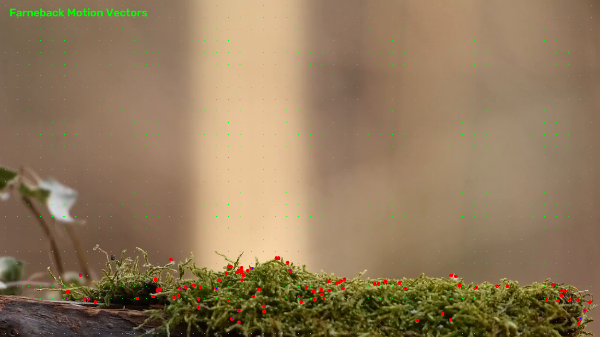


Video finished.

Video processing completed.


OPTICAL FLOW PERFORMANCE
Lucas-Kanade Average Time : 0.003989 sec/frame
Lucas-Kanade Approx FPS   : 250.69

Farneback Average Time    : 0.202829 sec/frame
Farneback Approx FPS      : 4.93


QUESTION 8 - ANALYSIS

1. OBJECT SPEED:
   Faster objects produce larger motion vectors.
   Very fast motion can make feature tracking difficult.

2. LIGHTING CONDITIONS:
   Optical flow works better when brightness remains relatively
   consistent between consecutive frames. Large illumination
   changes can reduce tracking accuracy.

3. CAMERA MOTION:
   Camera movement can produce optical flow throughout the image,
   even when objects themselves are stationary.

4. LUCAS-KANADE:
   Tracks selected feature points and therefore produces sparse
   optical flow.

5. FARNEBACK:
   Estimates motion over the entire image and therefore produces
   dense optical flow.



QUESTION 9 - APPLICATIONS

Lucas-Kanade:
- Object tracking
- Feature tracking
- Point t

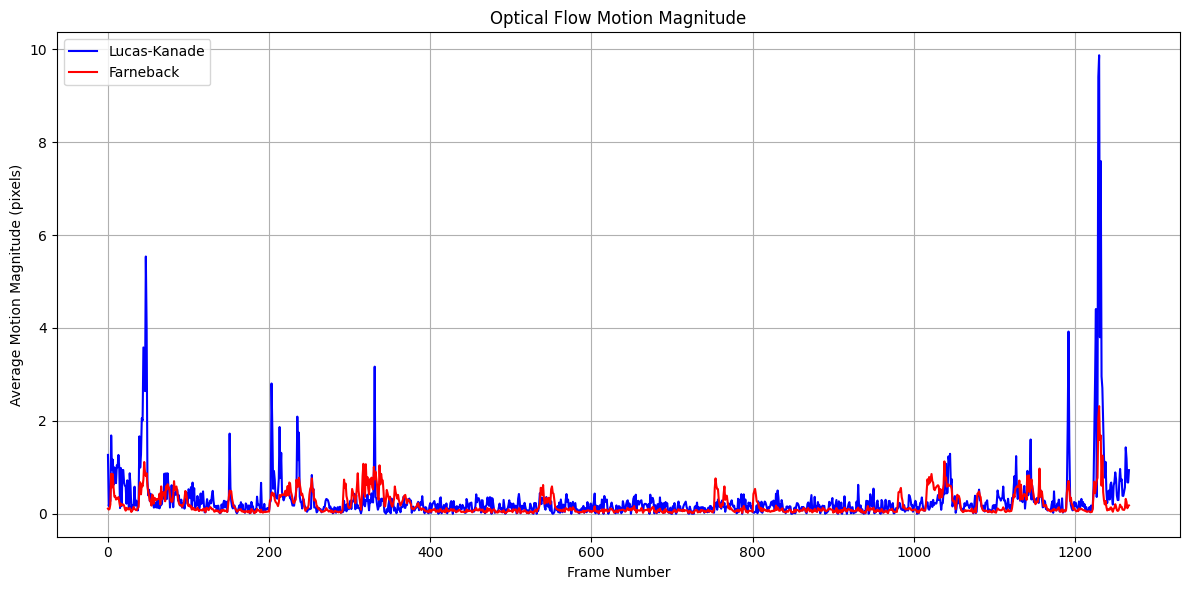



FINAL SUMMARY
Total processed frames : 1268
Lucas-Kanade FPS       : 250.69
Farneback FPS          : 4.93
PROGRAM COMPLETED SUCCESSFULLY


In [5]:

# OPTICAL FLOW USING LUCAS-KANADE AND FARNEBACK
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import os

from google.colab.patches import cv2_imshow
from IPython.display import display, clear_output
# TASK 1:IMPORT LIBRARIES AND LOAD VIDEO


VIDEO_SOURCE = "bird.mp4"

if not os.path.exists(VIDEO_SOURCE):
    raise FileNotFoundError(
        "ERROR: 'bird.mp4' was not found. "
        "Upload bird.mp4 to your Colab session."
    )

cap = cv2.VideoCapture(VIDEO_SOURCE)

if not cap.isOpened():
    raise RuntimeError("ERROR: Could not open the video.")

print("Video opened successfully!")

# Get video information
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("\nVideo Information")
print("-" * 40)
print("Width       :", width)
print("Height      :", height)
print("FPS         :", fps)
print("Total Frames:", total_frames)
# TASK 2: READ FIRST FRAME AND CONVERT TO GRAYSCALE

ret, old_frame = cap.read()

if not ret:
    cap.release()
    raise RuntimeError("ERROR: Could not read the first frame.")

old_gray = cv2.cvtColor(
    old_frame,
    cv2.COLOR_BGR2GRAY
)
# TASK 3:LUCAS-KANADE OPTICAL FLOW

# Shi-Tomasi corner detection parameters
feature_params = dict(
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)

# Lucas-Kanade parameters
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(
        cv2.TERM_CRITERIA_EPS |
        cv2.TERM_CRITERIA_COUNT,
        10,
        0.03
    )
)

# Detect feature points
p0 = cv2.goodFeaturesToTrack(
    old_gray,
    mask=None,
    **feature_params
)

# Mask for trajectories
lk_mask = np.zeros_like(old_frame)
# PERFORMANCE STORAGE

lk_times = []
fb_times = []

lk_motion_per_frame = []
fb_motion_per_frame = []

frame_count = 0
# TASK 5:
# FARNEBACK DENSE OPTICAL FLOW PARAMETERS

farneback_params = dict(
    pyr_scale=0.5,
    levels=3,
    winsize=15,
    iterations=3,
    poly_n=5,
    poly_sigma=1.2,
    flags=0
)
# TASK 6:
# CONVERT FLOW TO HSV COLOR VISUALIZATION

def flow_to_hsv(flow):

    magnitude, angle = cv2.cartToPolar(
        flow[..., 0],
        flow[..., 1]
    )

    hsv = np.zeros(
        (flow.shape[0], flow.shape[1], 3),
        dtype=np.uint8
    )

    # Direction
    hsv[..., 0] = (
        angle * 180 / np.pi / 2
    ).astype(np.uint8)

    # Saturation
    hsv[..., 1] = 255

    # Magnitude
    hsv[..., 2] = cv2.normalize(
        magnitude,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    return cv2.cvtColor(
        hsv,
        cv2.COLOR_HSV2BGR
    )
# DRAW DENSE OPTICAL FLOW VECTORS

def draw_dense_optical_flow(
    frame,
    flow,
    step=25
):

    output = frame.copy()

    h, w = flow.shape[:2]

    y, x = np.mgrid[
        step // 2:h:step,
        step // 2:w:step
    ].astype(int)

    for yy, xx in zip(
        y.flatten(),
        x.flatten()
    ):

        dx, dy = flow[yy, xx]

        start_point = (
            int(xx),
            int(yy)
        )

        end_point = (
            int(xx + dx),
            int(yy + dy)
        )

        cv2.arrowedLine(
            output,
            start_point,
            end_point,
            (0, 255, 0),
            1,
            tipLength=0.3
        )

    return output
# RESIZE FOR COLAB DISPLAY

display_width = 600

def resize_frame(img):

    h, w = img.shape[:2]

    scale = display_width / w

    new_h = int(h * scale)

    return cv2.resize(
        img,
        (display_width, new_h)
    )
# MAIN VIDEO PROCESSING LOOP

while True:

    ret, frame = cap.read()

    if not ret:
        print("\nVideo finished.")
        break

    frame_count += 1
    # TASK 2:
    # Convert current frame to grayscale

    frame_gray = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )
    # LUCAS-KANADE OPTICAL FLOW

    start_time = time.perf_counter()

    # Detect new features if required
    if p0 is None or len(p0) < 10:

        p0 = cv2.goodFeaturesToTrack(
            old_gray,
            mask=None,
            **feature_params
        )

        lk_mask = np.zeros_like(frame)

    current_lk_motion = []


    if p0 is not None:

        p1, status, error = cv2.calcOpticalFlowPyrLK(
            old_gray,
            frame_gray,
            p0,
            None,
            **lk_params
        )

        if (
            p1 is not None
            and status is not None
        ):

            good_new = p1[
                status.ravel() == 1
            ]

            good_old = p0[
                status.ravel() == 1
            ]
            # TASK 4:
            # DRAW LK TRAJECTORIES AND MOTION ARROWS

            for new, old in zip(
                good_new,
                good_old
            ):

                a, b = new.ravel()
                c, d = old.ravel()

                a = int(a)
                b = int(b)
                c = int(c)
                d = int(d)


                # Draw trajectory
                lk_mask = cv2.line(
                    lk_mask,
                    (a, b),
                    (c, d),
                    (0, 255, 255),
                    2
                )


                # Draw feature point
                cv2.circle(
                    frame,
                    (a, b),
                    4,
                    (0, 0, 255),
                    -1
                )


                # Draw motion arrow
                cv2.arrowedLine(
                    frame,
                    (c, d),
                    (a, b),
                    (255, 0, 0),
                    1,
                    tipLength=0.3
                )


                # Calculate displacement
                dx = a - c
                dy = b - d

                magnitude = np.sqrt(
                    dx ** 2 + dy ** 2
                )

                current_lk_motion.append(
                    magnitude
                )


            # Update feature points
            if len(good_new) > 0:

                p0 = good_new.reshape(
                    -1,
                    1,
                    2
                )

            else:

                p0 = None

        else:

            p0 = None


    lk_time = (
        time.perf_counter()
        - start_time
    )

    lk_times.append(lk_time)


    if len(current_lk_motion) > 0:

        lk_motion_per_frame.append(
            np.mean(current_lk_motion)
        )

    else:

        lk_motion_per_frame.append(0)


    # Combine original frame and trajectory mask
    lk_output = cv2.add(
        frame,
        lk_mask
    )
    # TASK 5:
    # FARNEBACK DENSE OPTICAL FLOW

    start_time = time.perf_counter()

    flow = cv2.calcOpticalFlowFarneback(
        old_gray,
        frame_gray,
        None,
        **farneback_params
    )

    fb_time = (
        time.perf_counter()
        - start_time
    )

    fb_times.append(fb_time)


    # Calculate motion magnitude
    magnitude, angle = cv2.cartToPolar(
        flow[..., 0],
        flow[..., 1]
    )

    average_fb_motion = np.mean(
        magnitude
    )

    fb_motion_per_frame.append(
        average_fb_motion
    )
    # TASK 6:COLOR-CODED FARNEBACK FLOW

    flow_color = flow_to_hsv(flow)


    # Draw dense motion vectors
    dense_vectors = draw_dense_optical_flow(
        frame,
        flow,
        step=25
    )
    # ADD TEXT TO OUTPUTS

    cv2.putText(
        lk_output,
        "Lucas-Kanade Optical Flow",
        (20, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 255),
        2
    )

    cv2.putText(
        flow_color,
        "Farneback Dense Optical Flow",
        (20, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    cv2.putText(
        dense_vectors,
        "Farneback Motion Vectors",
        (20, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )


    cv2.putText(
        lk_output,
        f"Frame: {frame_count}",
        (20, 65),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 255, 255),
        2
    )
    # RESIZE OUTPUTS

    lk_display = resize_frame(
        lk_output
    )

    fb_display = resize_frame(
        flow_color
    )

    vector_display = resize_frame(
        dense_vectors
    )

    # Display every 5th frame to avoid flooding the notebook.
    if frame_count % 5 == 0:

        clear_output(wait=True)

        print(
            f"Processing frame "
            f"{frame_count}/{total_frames}"
        )

        print(
            f"LK time: {lk_time:.5f} sec"
        )

        print(
            f"Farneback time: {fb_time:.5f} sec"
        )

        print("\n1. Lucas-Kanade Optical Flow")
        cv2_imshow(lk_display)

        print("\n2. Farneback Dense Optical Flow")
        cv2_imshow(fb_display)

        print("\n3. Farneback Motion Vectors")
        cv2_imshow(vector_display)


    # Update previous grayscale frame
    old_gray = frame_gray.copy()

cap.release()

print("\nVideo processing completed.")
# TASK 7:PERFORMANCE COMPARISON

if len(lk_times) > 0:

    avg_lk_time = np.mean(
        lk_times
    )

    avg_lk_fps = (
        1 / avg_lk_time
        if avg_lk_time > 0
        else 0
    )

else:

    avg_lk_time = 0
    avg_lk_fps = 0


if len(fb_times) > 0:

    avg_fb_time = np.mean(
        fb_times
    )

    avg_fb_fps = (
        1 / avg_fb_time
        if avg_fb_time > 0
        else 0
    )

else:

    avg_fb_time = 0
    avg_fb_fps = 0


print("\n")
print("=" * 60)
print("OPTICAL FLOW PERFORMANCE")
print("=" * 60)

print(
    f"Lucas-Kanade Average Time : "
    f"{avg_lk_time:.6f} sec/frame"
)

print(
    f"Lucas-Kanade Approx FPS   : "
    f"{avg_lk_fps:.2f}"
)

print()

print(
    f"Farneback Average Time    : "
    f"{avg_fb_time:.6f} sec/frame"
)

print(
    f"Farneback Approx FPS      : "
    f"{avg_fb_fps:.2f}"
)
# TASK 8:

print("\n")
print("=" * 60)
print("QUESTION 8 - ANALYSIS")
print("=" * 60)

print("""
1. OBJECT SPEED:
   Faster objects produce larger motion vectors.
   Very fast motion can make feature tracking difficult.

2. LIGHTING CONDITIONS:
   Optical flow works better when brightness remains relatively
   consistent between consecutive frames. Large illumination
   changes can reduce tracking accuracy.

3. CAMERA MOTION:
   Camera movement can produce optical flow throughout the image,
   even when objects themselves are stationary.

4. LUCAS-KANADE:
   Tracks selected feature points and therefore produces sparse
   optical flow.

5. FARNEBACK:
   Estimates motion over the entire image and therefore produces
   dense optical flow.
""")
# TASK 9:APPLICATIONS

print("\n")
print("=" * 60)
print("QUESTION 9 - APPLICATIONS")
print("=" * 60)

print("""
Lucas-Kanade:
- Object tracking
- Feature tracking
- Point tracking
- Camera motion estimation
- Real-time applications

Farneback:
- Dense motion estimation
- Motion detection
- Video analysis
- Surveillance
- Scene understanding
- Motion segmentation
""")

# TASK 10:
# CONCLUSION

print("\n")
print("=" * 60)
print("QUESTION 10 - CONCLUSION")
print("=" * 60)

print("""
Optical flow is used to estimate apparent motion between
consecutive video frames.

Lucas-Kanade estimates the motion of selected feature points,
whereas Farneback estimates a dense motion field across the
image.

Lucas-Kanade can be useful for feature and object tracking,
while Farneback can be used when motion information across the
image is required.

Optical flow is widely used in computer vision applications such
as object tracking, surveillance, motion detection, autonomous
navigation, video analysis, and dynamic scene understanding.
""")
# PLOT MOTION MAGNITUDE

plt.figure(
    figsize=(12, 6)
)


if len(lk_motion_per_frame) > 0:

    plt.plot(
        lk_motion_per_frame,
        label="Lucas-Kanade",
        color="blue"
    )


if len(fb_motion_per_frame) > 0:

    plt.plot(
        fb_motion_per_frame,
        label="Farneback",
        color="red"
    )


plt.title(
    "Optical Flow Motion Magnitude"
)

plt.xlabel(
    "Frame Number"
)

plt.ylabel(
    "Average Motion Magnitude (pixels)"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()
# FINAL SUMMARY

print("\n")
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(
    f"Total processed frames : {frame_count}"
)

print(
    f"Lucas-Kanade FPS       : {avg_lk_fps:.2f}"
)

print(
    f"Farneback FPS          : {avg_fb_fps:.2f}"
)

print("=" * 60)
print("PROGRAM COMPLETED SUCCESSFULLY")
print("=" * 60)